# Model Interpretability

This notebook extracts and visualizes feature importances from our selected candidate model: **Decision Tree Regressor (`max_depth=3`)**. We analyze which features contribute most to reducing target variance during training and discuss their domain relevance.



## 1. Load Data and Train Selected Pipeline



In [1]:
import pandas as pd
import numpy as np
import os
import sys

# Append parent directory to sys.path to allow importing src
sys.path.append(os.path.abspath(".."))

from src.features.preprocessing import build_preprocessor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

# Load preprocessed dataset
df = pd.read_csv("../data/processed/mxmh_cleaned.csv")
y = df["Anxiety"]
X = df.drop(columns=["Anxiety", "Depression", "Insomnia", "OCD"])

categorical_cols = list(X.select_dtypes(include=["object", "category"]).columns)
numerical_cols = list(X.select_dtypes(include=["int64", "float64"]).columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build and fit pipeline
preprocessor = build_preprocessor(numerical_cols, categorical_cols)
model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", DecisionTreeRegressor(max_depth=3, random_state=42))
])
model_pipeline.fit(X_train, y_train)



C:\Users\aksha\AppData\Local\Temp\ipykernel_41352\3818304561.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = list(X.select_dtypes(include=["object", "category"]).columns)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['Age','Primary streaming service','Hours per day',...,'Frequency [Rock]', 'Frequency [Video game music]','Music effects']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will 

## 2. Extract Feature Importances

We extract the Gini importances from the fitted Decision Tree estimator and match them with feature names from the ColumnTransformer.



In [2]:
# Get estimator and preprocessor
dt_model = model_pipeline.named_steps["regressor"]
transformer = model_pipeline.named_steps["preprocessor"]

# Retrieve one-hot encoded categorical feature names
ohe_names = transformer.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_cols)

# Combine with numerical feature names
all_feature_names = list(numerical_cols) + list(ohe_names)

# Extract importances
importances = dt_model.feature_importances_

# Create a DataFrame
importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Filter out features with 0 importance
active_importances = importance_df[importance_df["Importance"] > 0]
print(active_importances)



                         Feature  Importance
0                            Age    0.365112
14               Frequency [Pop]    0.264431
6               Frequency [Folk]    0.113249
18  Frequency [Video game music]    0.107079
10             Frequency [K pop]    0.089159
15               Frequency [R&B]    0.060970


## 3. Visualize Feature Contributions

We plot the non-zero feature importances of our regularized tree.



C:\Users\aksha\AppData\Local\Temp\ipykernel_41352\196445192.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


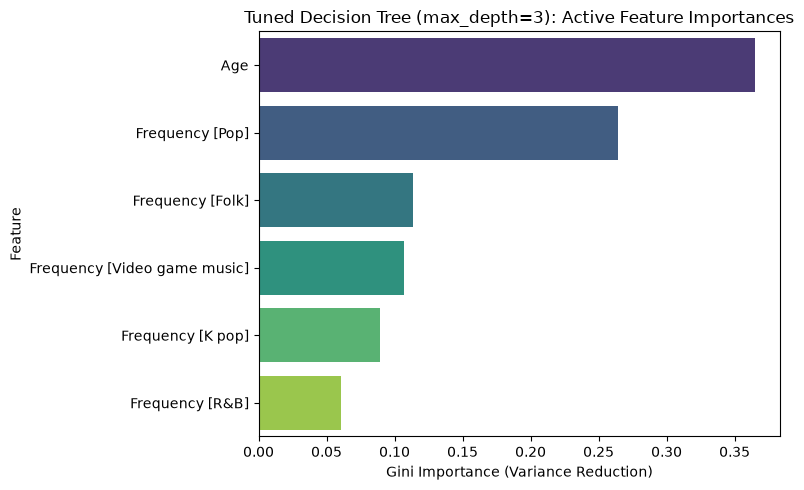

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(
    data=active_importances,
    x="Importance",
    y="Feature",
    palette="viridis"
)
plt.title("Tuned Decision Tree (max_depth=3): Active Feature Importances")
plt.xlabel("Gini Importance (Variance Reduction)")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../docs/figures/tuned_dt_feature_importance.png", dpi=120)
plt.show()

